# Back-projecting a tsunami source: dispersive walkthrough

**Event:** 2025-07-30 M8.8 Kamchatka earthquake &nbsp;&bull;&nbsp; **Package:** `tsbp` (ray tracing via `TsunamiTrace`)

This is the dispersive companion to [`non-dispersive-demo.ipynb`](non-dispersive-demo.ipynb).
Read that one first: the back-projection idea, the config layout, and the misfit maps
are the same. Here we change **one thing, the wave physics.**

The crests here come from a **40-50 km band-pass** of the SWOT sea-surface height, so
they are *not* long waves. At a 45 km wavelength in multi-km water the wave feels the
finite depth: it is **dispersive**, and its energy travels at the **group speed**,
which is noticeably slower than the shallow-water `sqrt(g*h)`. Getting the travel times
right, and therefore the inferred source, requires tracing that group speed, not
`sqrt(g*h)`.

We drive this with the self-contained config [`bandpass_40_50.yaml`](bandpass_40_50.yaml)
and the same bundled bathymetry and SWOT data as the non-dispersive demo. **For speed
we back-project only 2 of the 10 band-passed crests** (all 10 are plotted below).

## 1. Setup

In [1]:
import os, sys, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from IPython.display import Image, display

import tsbp
from tsbp.config import load_config
from tsbp.io import load_domain_bathymetry, load_wf_polyline

assert Path("data").is_dir(), "run this notebook from the examples/ directory"
cfg = load_config("bandpass_40_50.yaml")
DEMO = [w.name for w in cfg.wavefronts]          # crests actually back-projected
print("tsbp", tsbp.__version__, "| back-projecting crests", DEMO, "of the 10-crest band")

tsbp 0.1.0 | back-projecting crests ['2', '7'] of the 10-crest band


## 2. The band-passed crests

The 40-50 km band-pass isolates a *train* of later, dispersed crests trailing the
leading wave. Ten were digitised; they sweep from south to north as the swath was
imaged. We plot all ten over the bathymetry and highlight the two this demo
back-projects.

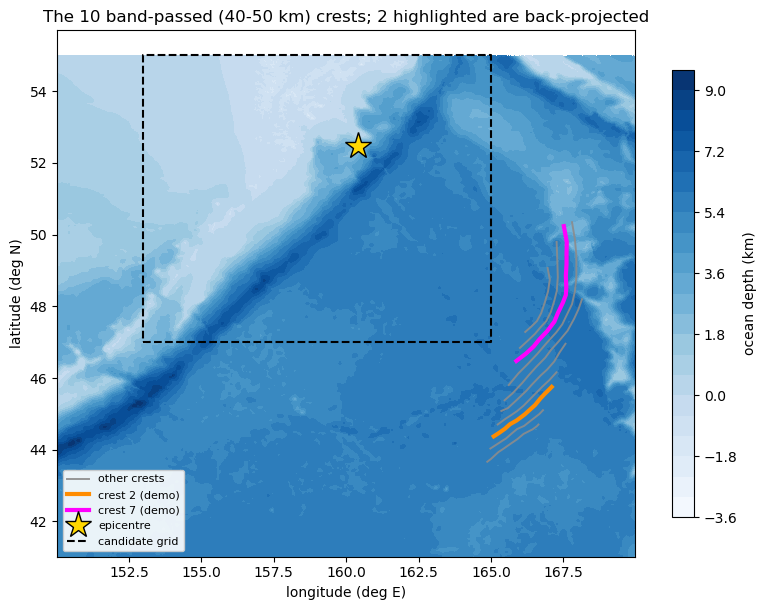

In [2]:
blon, blat, depth = load_domain_bathymetry(cfg)

# warm, non-blue colours for the demo crests so they read over the blue bathymetry
demo_colors = dict(zip(DEMO, ["darkorange", "magenta"]))

fig, ax = plt.subplots(figsize=(8, 6.2))
cf = ax.contourf(blon, blat, depth.T / 1000.0, levels=20, cmap="Blues")
plt.colorbar(cf, ax=ax, label="ocean depth (km)", shrink=0.85)

for i in range(10):
    pts = load_wf_polyline(f"data/bandpass_40_50_{i}.geojson")
    if str(i) in DEMO:
        ax.plot(pts[:, 0], pts[:, 1], "-", lw=3, color=demo_colors[str(i)],
                label=f"crest {i} (demo)", zorder=5)
    else:
        ax.plot(pts[:, 0], pts[:, 1], "-", lw=1.4, color="0.55", alpha=0.9,
                label="other crests" if i == 0 else None)

ax.plot(cfg.epi_lon, cfg.epi_lat, "*", ms=20, mec="k", mfc="gold", label="epicentre")
cl, ct = cfg.cand_lon, cfg.cand_lat
ax.plot([cl[0], cl[1], cl[1], cl[0], cl[0]], [ct[0], ct[0], ct[1], ct[1], ct[0]],
        "k--", lw=1.5, label="candidate grid")
ax.set(xlabel="longitude (deg E)", ylabel="latitude (deg N)",
       title="The 10 band-passed (40-50 km) crests; 2 highlighted are back-projected")
ax.legend(loc="lower left", fontsize=8, framealpha=0.9)
plt.tight_layout()

## 3. Why dispersion matters here

A wave of wavelength $\lambda$ in water of depth $h$ has angular frequency
$\omega=\sqrt{g\,k\tanh(kh)}$ with $k=2\pi/\lambda$. Its **group speed** (the speed of
energy and hence of travel time) is

$$c_g=\frac{\omega}{k}\cdot\tfrac12\!\left(1+\frac{2kh}{\sinh 2kh}\right).$$

In the shallow-water limit ($kh\to0$) this collapses to $\sqrt{gh}$. But a 45 km wave
in the 5 to 6 km deep NW Pacific has $kh\sim0.8$, squarely intermediate depth, so
$c_g$ runs well below $\sqrt{gh}$. `tsbp` traces exactly this $c_g$.

`local_wavelength: 45000` in the config means **45 km was measured in situ on the
band-passed SWOT data**. The engine pins $\omega$ from that wavelength at each crest's
reference depth (the median depth under its points) and then traces $c_g$
everywhere.

omega pinned by 45 km at 5700 m: 0.0301 rad/s  (period 209 s)
at 5700 m: c_group = 181 m/s vs sqrt(gh) = 236 m/s  ->  24% slower


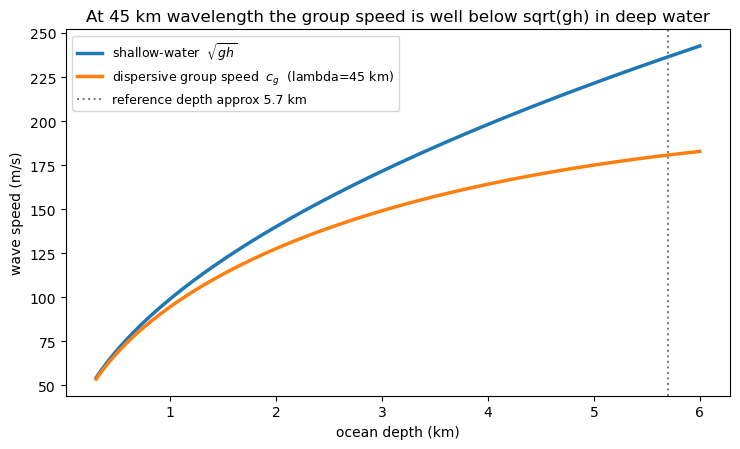

In [3]:
g, lam = 9.81, 45000.0
h_ref = 5700.0                                   # approx the crests' reference depth
k0 = 2 * np.pi / lam
omega0 = np.sqrt(g * k0 * np.tanh(k0 * h_ref))   # omega pinned by lambda at h_ref

def cg_dispersive(h, omega):
    k = brentq(lambda k: g * k * np.tanh(k * h) - omega**2, 1e-7, 1.0)
    kh = k * h
    return (omega / k) * 0.5 * (1 + 2 * kh / np.sinh(2 * kh))

h = np.linspace(300, 6000, 250)
c_group   = np.array([cg_dispersive(hi, omega0) for hi in h])
c_shallow = np.sqrt(g * h)

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.plot(h / 1000, c_shallow, lw=2.5, label=r"shallow-water  $\sqrt{gh}$")
ax.plot(h / 1000, c_group,   lw=2.5, label=r"dispersive group speed  $c_g$  (lambda=45 km)")
ax.axvline(h_ref / 1000, color="0.5", ls=":", label=f"reference depth approx {h_ref/1000:.1f} km")
ax.set(xlabel="ocean depth (km)", ylabel="wave speed (m/s)",
       title="At 45 km wavelength the group speed is well below sqrt(gh) in deep water")
ax.legend(fontsize=9); plt.tight_layout()

slow = 100 * (1 - cg_dispersive(h_ref, omega0) / np.sqrt(g * h_ref))
print(f"omega pinned by 45 km at {h_ref:.0f} m: {omega0:.4f} rad/s  (period {2*np.pi/omega0:.0f} s)")
print(f"at {h_ref:.0f} m: c_group = {cg_dispersive(h_ref, omega0):.0f} m/s "
      f"vs sqrt(gh) = {np.sqrt(g*h_ref):.0f} m/s  ->  {slow:.0f}% slower")

## 4. The config

Same structure as the non-dispersive demo; the differences are all about the wave:

- **`wavefronts[].local_wavelength: 45000`** replaces `wavelength: null`. This is the
  in-situ (band-pass) wavelength in metres; it switches the engine into dispersive
  (group-speed) tracing. `local_depth` is omitted, so each crest sets its own
  reference depth from the bathymetry under its points.
- The `event.rupture_speed_kms` still feeds the *anchored* map, but for these later,
  dispersed crests the **origin-time-free** map is the more trustworthy one: the
  emission time of a trailing crest is genuinely uncertain.
- Demo-only trims (see the header comment): **2 crests instead of 10**, a coarser
  `azimuth_step_deg` (0.10 vs 0.05), and **no source bootstrap**.

In [4]:
print(Path("bandpass_40_50.yaml").read_text())

# Self-contained DISPERSIVE back-projection demo: 2025-07-30 M8.8 Kamchatka.
#
# Runnable twin of ../configs/bandpass_40_50.yaml, pointing at the small bundled
# subsets in ./data/.  Run from THIS directory (examples/):
#
#     cd examples
#     tsbp --config bandpass_40_50.yaml
#
# These are 40-50 km BAND-PASSED SWOT crests.  The wave is specified by its
# in-situ (locally measured) wavelength via `local_wavelength`: 45 km = 45000 m
# was measured on the band-passed SWOT data.  The engine converts it to the
# invariant angular frequency omega with sqrt(g*k*tanh(k*h)) at a reference depth
# and traces the dispersive GROUP speed.  (Do NOT use the deep-water `wavelength`
# field for band-passed crests -- that is a different quantity.)
#
# Three deliberate differences from the paper config, to keep this a SHORT demo:
#   * only 2 of the 10 crests are back-projected here (an earlier southern crest
#     and a later northern one); all 10 are shipped in data/ and plotted in the
#     noteboo

## 5. Run it

Two crests, dispersive tracing, about 1.5 minutes.

In [5]:
subprocess.run([sys.executable, "-m", "tsbp", "--config", "bandpass_40_50.yaml"],
               check=True,
               stderr=subprocess.DEVNULL)  # hide per-point progress bars; reports still stream

Wavefronts to back-project: ['2', '7']
Loading + subsetting bathymetry ...
  domain 150.0..170.0 E, 41.0..55.0 N -> depth (600, 420)
  candidate grid 121 x 81 cells

========== wavefront: bp4050_2 ==========
Loading WF polyline ...
  60 WF points (resampled from 13), lon 165.09..167.09, lat 44.37..45.75
  local_depth not given -> median WF bathymetric depth 5752.3 m used as the reference for local_wavelength=45000 m
Matching SWOT per-pixel times: data/swot_times.csv
  per-pixel arrival 69.44..69.92 min (mean 69.67); nearest-pixel match 0.2..2.1 km
Raw coverage diagnostic (fill=False) ...

--- forward consistency (trace FROM configured epicentre) ---
  model travel time epicentre -> WF: 82.7..89.5 min, mean 85.71 min
  observed (anchor) arrival times:    69.4..69.9 min, mean 69.67 min
  gap (model - observed):             mean +16.04 min, range +12.75..+20.06  <-- INCONSISTENT
  => the anchored arc will sit off the epicentre by this much in travel time;
     reconcile the epicentre / ar

CompletedProcess(args=['/Users/dmelgarm/opt/anaconda3/envs/tsunamitrace/bin/python', '-m', 'tsbp', '--config', 'bandpass_40_50.yaml'], returncode=0)

## 6. Results

First, confirm the run really was dispersive. The printed comparison table has a
`wavelength` column that only tracks the *deep-water* `wavelength` field, so it labels
`local_wavelength` runs as "shallow". The saved arrays carry the truth: a finite wave
**period** and each crest's **reference depth**.

In [6]:
for name in DEMO:
    d = np.load(f"output/bp4050_{name}.npz")
    print(f"crest {name}: local_wavelength = {float(d['local_wavelength']):.0f} m, "
          f"period = {float(d['period']):.0f} s, "
          f"reference depth = {float(d['ref_depth']):.0f} m  (dispersive)")

crest 2: local_wavelength = 45000 m, period = 208 s, reference depth = 5752 m  (dispersive)
crest 7: local_wavelength = 45000 m, period = 207 s, reference depth = 5874 m  (dispersive)


In [7]:
summary = pd.read_csv("output/bp4050_summary.csv")
summary

,wavefront,wavelength_m,n_points,anc_lon,anc_lat,anc_misfit_min,anc_offset_km,anc_valley_ew_km,anc_valley_ns_km,anc_resid_min,geom_lon,geom_lat,geom_misfit_min,geom_offset_km,free_lon,free_lat,free_misfit_min,free_offset_km
0,2,shallow,60,158.8,49.4,0.312,359.5,168.0,256.0,0.247,161.6,48.1,0.137,493.7,161.4,48.1,0.142,491.4
1,7,shallow,60,157.4,49.5,0.818,391.4,42.0,200.0,0.191,162.0,49.2,0.274,380.9,161.9,49.1,0.272,389.7


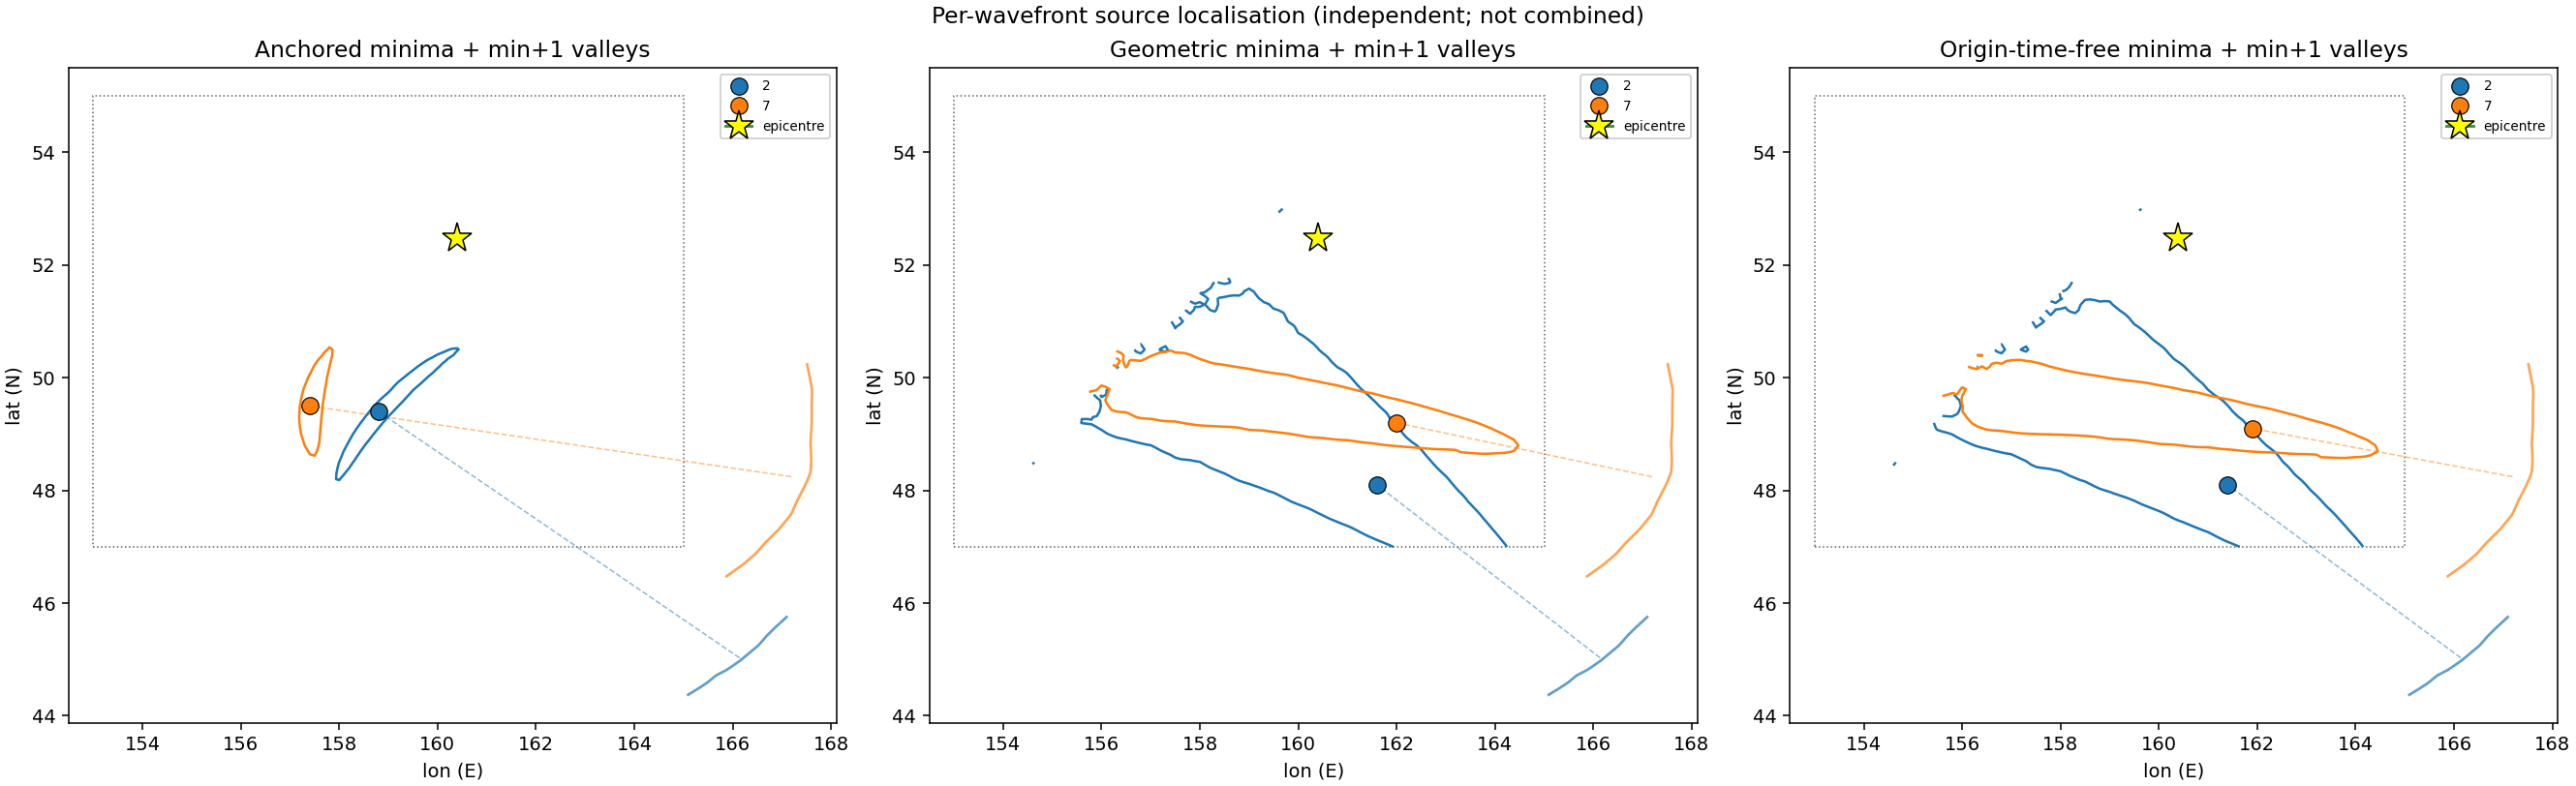

In [8]:
display(Image(filename="output/bp4050_compare.png"))

For a dispersed, trailing crest the **origin-time-free** map is the one to read
(it marginalises out the uncertain emission time). Here is crest 7's free-misfit map
straight from its `.npz`:

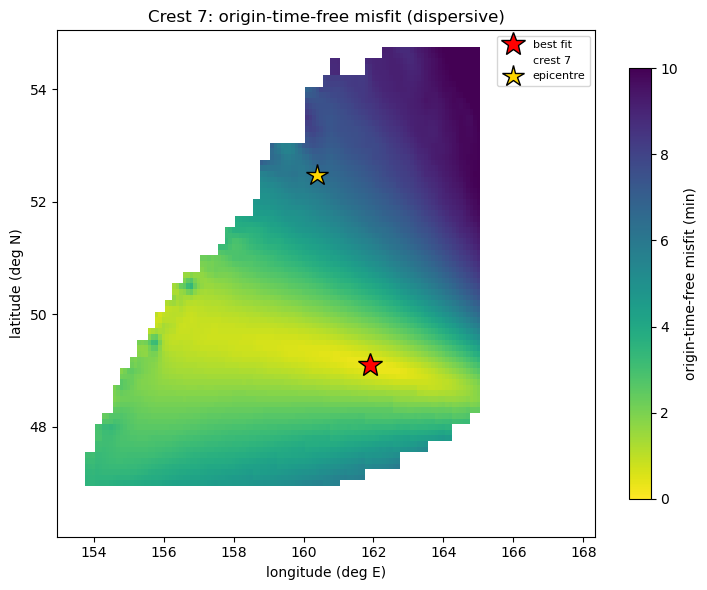

In [9]:
feat = DEMO[-1]                                   # crest 7
d = np.load(f"output/bp4050_{feat}.npz")
clon, clat, free = d["clon"], d["clat"], d["std_free"]
pts = load_wf_polyline(f"data/bandpass_40_50_{feat}.geojson")

fig, ax = plt.subplots(figsize=(7.5, 6))
pc = ax.pcolormesh(clon, clat, free, cmap="viridis_r", vmin=0, vmax=cfg.misfit_vmax,
                   shading="auto")
plt.colorbar(pc, ax=ax, label="origin-time-free misfit (min)", shrink=0.85)
jmin = np.unravel_index(np.nanargmin(free), free.shape)
ax.plot(clon[jmin[1]], clat[jmin[0]], "r*", ms=18, mec="k", label="best fit")
ax.plot(pts[:, 0], pts[:, 1], "w-", lw=2.5, label=f"crest {feat}")
ax.plot(cfg.epi_lon, cfg.epi_lat, "k*", ms=16, mfc="gold", label="epicentre")
ax.set(xlabel="longitude (deg E)", ylabel="latitude (deg N)",
       title=f"Crest {feat}: origin-time-free misfit (dispersive)")
ax.legend(loc="upper right", fontsize=8); plt.tight_layout()

## 7. Takeaways

- **Only the physics changed.** Swapping `wavelength: null` for `local_wavelength:
  45000` re-traces the crests at the dispersive group speed; everything else (the
  candidate grid, the misfit maps, the emission-time search) is identical to the
  non-dispersive demo.
- **Dispersion slows the wave** by about 20 to 25% at these wavelengths and depths,
  which shifts inferred travel times (and sources) relative to a `sqrt(g*h)` treatment.
- **Read the free map** for these trailing crests; the anchored map assumes an emission
  time (via the rupture delay) that a dispersed later crest does not pin down.
- The single-crest **arc degeneracy** is the same story as before: each crest gives a
  broad valley; several crests together localise the source.

## Next steps

- **Full paper run:** `configs/bandpass_40_50.yaml` back-projects **all 10** crests at
  the finer `azimuth_step_deg: 0.05` **and** runs a 200x **source bootstrap** per
  crest, writing a `boot_*.npz` cloud that quantifies source-location uncertainty.
- Compare a crest's dispersive source here against its shallow-water source in the
  non-dispersive demo to see how much the wave physics moves the answer.